# 1. Préliminaires


# 1.1 Contexte 
AI Worker Burnout Attrition : [Dataset](https://www.kaggle.com/datasets/nudratabbas/ai-worker-burnout-and-attrition-risk-dataset/data)


Ce dataset utilisé dans ce repository pour pratiquer l'analyse de donnée.


## 1.2 Importations des librairies

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## 1.3 Chargement des données

In [2]:
# chargement des données
data = pd.read_csv('./data/ai_worker_burnout_attrition_2026.csv')

# Affichage d'un extrait
data.head()

,employee_id,job_role,years_experience,education_level,country,industry,company_size,remote_work_type,team_size,salary_usd_k,...,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,ai_adoption_stage,weekly_ai_upskilling_hrs,productivity_score,burnout_score,job_satisfaction_1_5,fear_of_ai_replacement,attrition_risk
0,EMP0001,Data Analyst,7,PhD,India,Healthtech,Large (1000-5000),Fully Remote,8,184,...,1,0.6,37,Experimenting,4.9,59,58,3.0,Low,Medium
1,EMP0002,DevOps Engineer,3,Self-taught,Canada,Fintech,Large (1000-5000),Hybrid,42,51,...,3,0.6,78,Experimenting,6.6,64,47,3.6,Medium,Medium
2,EMP0003,Prompt Engineer,3,PhD,India,Automotive,Startup (<50),Hybrid,37,185,...,4,4.0,23,Optimizing,5.8,50,37,4.6,High,Medium
3,EMP0004,Backend Engineer,18,Master,Germany,Media,Mid (200-1000),Fully Remote,8,131,...,5,4.2,75,Integrating,1.4,77,67,3.0,Low,Medium
4,EMP0005,AI Researcher,5,Bachelor,India,E-commerce,Small (50-200),Fully Remote,21,99,...,7,0.7,61,Experimenting,1.6,58,54,3.6,Medium,Medium


## 1.4 Structure et Typologie des données

In [3]:
data.shape

(1500, 21)

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   employee_id                     1500 non-null   str    
 1   job_role                        1500 non-null   str    
 2   years_experience                1500 non-null   int64  
 3   education_level                 1500 non-null   str    
 4   country                         1500 non-null   str    
 5   industry                        1500 non-null   str    
 6   company_size                    1500 non-null   str    
 7   remote_work_type                1500 non-null   str    
 8   team_size                       1500 non-null   int64  
 9   salary_usd_k                    1500 non-null   int64  
 10  primary_ai_tool                 1500 non-null   str    
 11  ai_tools_used_per_day           1500 non-null   int64  
 12  hours_with_ai_assistance_daily  1500 non-null

In [5]:
# selections des colonnes categorielles
categorical_cols = [
    "attrition_risk",
    "fear_of_ai_replacement",
    "ai_adoption_stage",
    "ai_tools_used_per_day",
    "primary_ai_tool",
    "education_level",
    "country",
    "industry",
    "company_size",
    "remote_work_type"
]

# changement du type en categorie
data[categorical_cols]= data[categorical_cols].astype('category')

In [6]:
data.nunique()

employee_id                       1500
job_role                            12
years_experience                    19
education_level                      5
country                             10
industry                            10
company_size                         5
remote_work_type                     3
team_size                           48
salary_usd_k                       210
primary_ai_tool                      8
ai_tools_used_per_day                7
hours_with_ai_assistance_daily      76
ai_replaces_my_tasks_pct            75
ai_adoption_stage                    4
weekly_ai_upskilling_hrs           101
productivity_score                  62
burnout_score                       66
job_satisfaction_1_5                37
fear_of_ai_replacement               3
attrition_risk                       3
dtype: int64

## 1.5 Choix des colonnes quantitatives

In [7]:
features = [
    "years_experience",
    "team_size",
    "salary_usd_k",
    "ai_tools_used_per_day",
    "hours_with_ai_assistance_daily",
    "ai_replaces_my_tasks_pct",
    "weekly_ai_upskilling_hrs",
    "burnout_score",
    "productivity_score",
]
df = data[features]
df.head()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,burnout_score,productivity_score
0,7,8,184,1,0.6,37,4.9,58,59
1,3,42,51,3,0.6,78,6.6,47,64
2,3,37,185,4,4.0,23,5.8,37,50
3,18,8,131,5,4.2,75,1.4,67,77
4,5,21,99,7,0.7,61,1.6,54,58


# 2. Exploration et préparation des données
Recherchons les erreurs.

## 2.1 Nettoyage

In [14]:
# Affichage de la sortie de .describe()
df.describe()

,years_experience,team_size,salary_usd_k,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,burnout_score,productivity_score
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,9.947333,24.812667,140.734000,4.233733,41.248667,4.985533,50.057333,57.543333
std,5.460932,13.682582,59.717429,2.148387,21.658214,2.913933,11.437771,10.726952
min,1.000000,2.000000,40.000000,0.500000,5.000000,0.000000,16.000000,25.000000
25%,5.000000,13.000000,91.000000,2.400000,22.750000,2.400000,42.000000,50.000000
50%,10.000000,25.000000,139.000000,4.200000,40.000000,5.000000,50.000000,57.000000
75%,15.000000,36.000000,190.000000,6.100000,60.000000,7.500000,58.000000,65.000000
max,19.000000,49.000000,249.000000,8.000000,79.000000,10.000000,86.000000,95.000000


In [15]:
# vérification de  valeurs manquantes
df.isna().sum()

years_experience                  0
team_size                         0
salary_usd_k                      0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
weekly_ai_upskilling_hrs          0
burnout_score                     0
productivity_score                0
dtype: int64

In [16]:
# vérification des valeurs nulles
df.isnull().sum()

years_experience                  0
team_size                         0
salary_usd_k                      0
ai_tools_used_per_day             0
hours_with_ai_assistance_daily    0
ai_replaces_my_tasks_pct          0
weekly_ai_upskilling_hrs          0
burnout_score                     0
productivity_score                0
dtype: int64

In [17]:
# vérification des valeurs dupliquées
df.duplicated().sum()

np.int64(0)

In [18]:
# vérification du nombre de valuers uniques
df.nunique()

years_experience                   19
team_size                          48
salary_usd_k                      210
ai_tools_used_per_day               7
hours_with_ai_assistance_daily     76
ai_replaces_my_tasks_pct           75
weekly_ai_upskilling_hrs          101
burnout_score                      66
productivity_score                 62
dtype: int64

## 2.2 Matrice des corrélations

In [56]:
# matrice des corrélations
corr_matrix = df.corr()

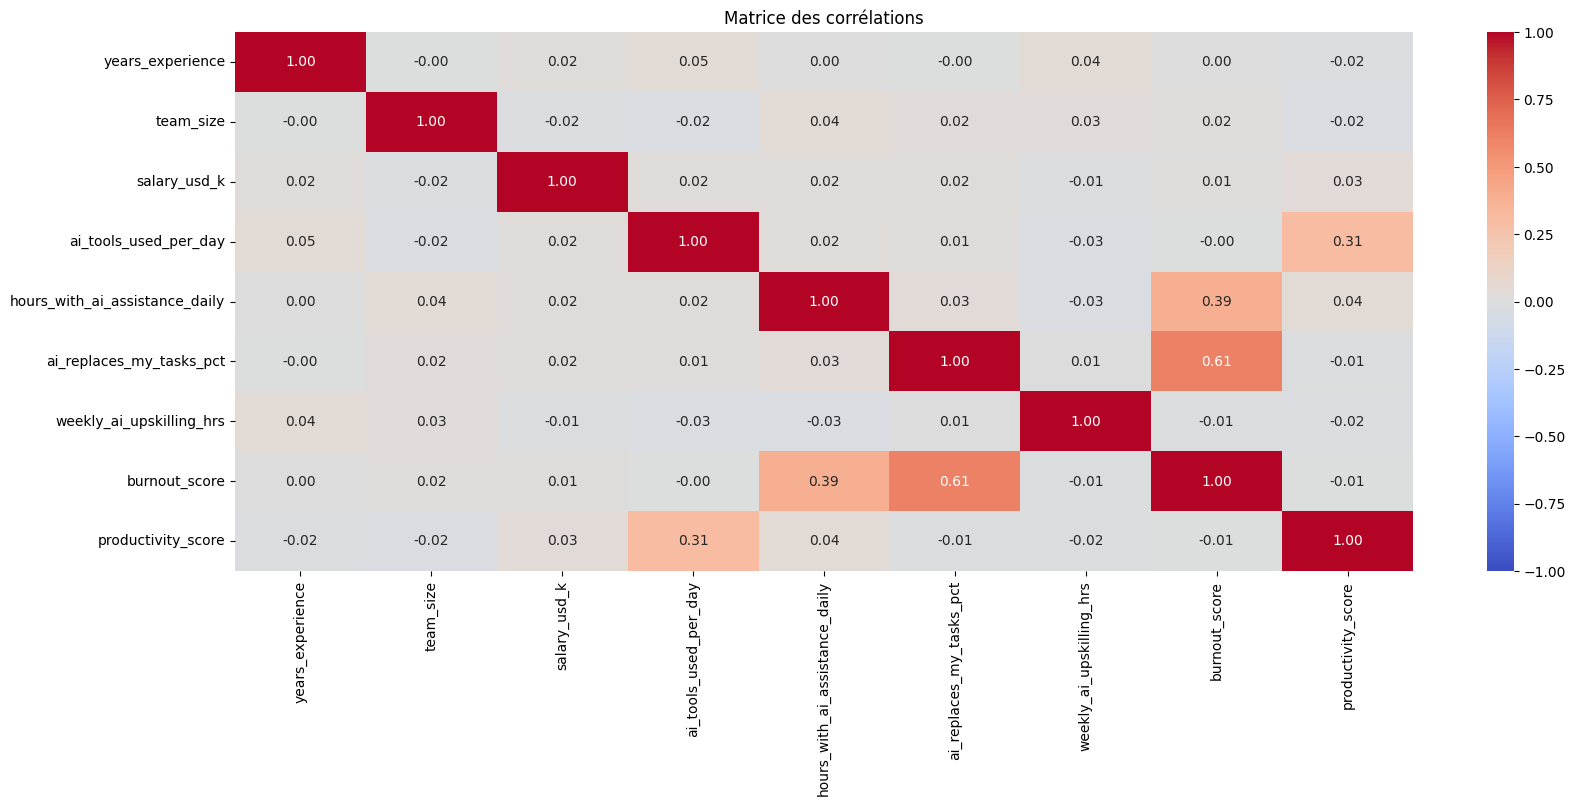

In [57]:
# initialisation du graphique
plt.figure(figsize=(19, 7))

# carte de chaleur
sns.heatmap(data=corr_matrix, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt=".2f",linewidths=0.5)

plt.title("Matrice des corrélations")

# affichage
plt.show()

## 2.3 Standarisation des données

In [58]:
# Récuperation de la matrice des données
X = df.values

In [59]:
# initialisation du scaler
scaler = StandardScaler()

# récuperation de la matrice centrée réduite
X_Scaled = scaler.fit_transform(X)

# Affichage d'un extrait sous forme de dataframe
pd.DataFrame(X_Scaled).head()

,0,1,2,3,4,5,6,7,8
0,-0.539893,-1.229174,0.724754,-1.548618,-1.691942,-0.196234,-0.029363,0.694656,0.135840
1,-1.272613,1.256566,-1.503145,-0.535125,-1.691942,1.697443,0.554236,-0.267391,0.602111
2,-1.272613,0.891016,0.741505,-0.028378,-0.108831,-0.842856,0.279601,-1.141978,-0.703448
3,1.475088,-1.229174,-0.163055,0.478369,-0.015707,1.558882,-1.230889,1.481785,1.814416
4,-0.906253,-0.278744,-0.699091,1.491863,-1.645380,0.912260,-1.162231,0.344821,0.042586


In [60]:
# vérification du résultat de la standarisation
pd.DataFrame(X_Scaled).describe().round().loc[["mean","std"]]

,0,1,2,3,4,5,6,7,8
mean,0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


# 3. Analyse par composantes principales

## 3.1 Initialisation et entrainement du PCA

In [61]:
# nombre de composantes
n_components=9

# initialisation du PCA
pca = PCA(n_components=n_components)

# entrainement du PCA
pca.fit(X_Scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",9
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

## 3.2 Variance expliquée

In [62]:
# récuperation de la variance expliquée par chaque composante
scree = (pca.explained_variance_ratio_*100).round(2)

# affichage
scree

array([19.38, 14.74, 11.64, 11.34, 11.02, 10.72, 10.35,  7.58,  3.22])

In [63]:
# récupération de la variance expliquée cumulée
scree_cum= np.cumsum(scree).round()
scree_cum

array([ 19.,  34.,  46.,  57.,  68.,  79.,  89.,  97., 100.])

Maintenant passons au diagramme d'éboulis des valeurs propres.

In [64]:
# initialisation d'une liste de rang de chaque composante
x_list = [str(i+1) for i in range(len(features))]

# affichage
x_list

['1', '2', '3', '4', '5', '6', '7', '8', '9']

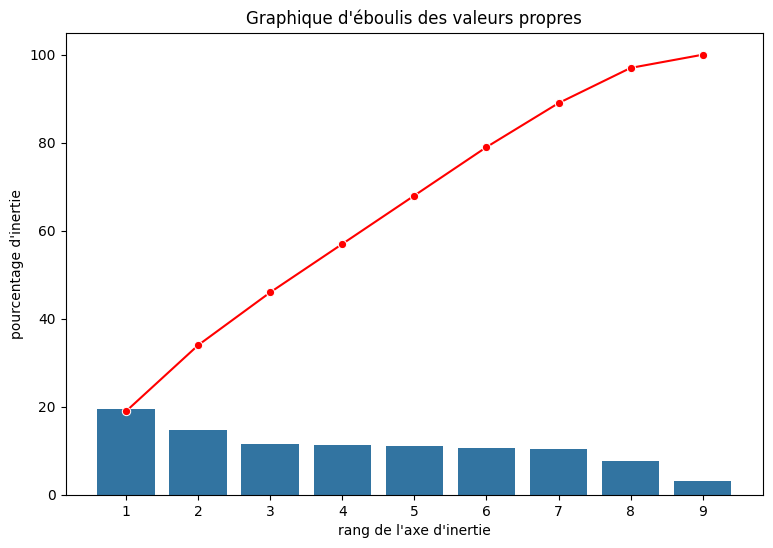

In [65]:
# graphique

# initialisation de la figure
plt.figure(figsize=(9,6))

# Diagramme à barre des variances expliquées
sns.barplot(x=x_list,y=scree)

# Courbe de la variance expliquée cumulée
sns.lineplot(x=x_list,y=scree_cum,marker='o',c='red')

# labels des axes
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")

# titre du graphique
plt.title("Graphique d'éboulis des valeurs propres")

# affichage du graphique
plt.show()

## 3.3 Composantes
Interessons nous maintenants aux composantes.

In [66]:
# récuperation de la matrice des composantes
pcs = pca.components_

# transformation en dataframe
pcs = pd.DataFrame(pcs,columns=features,index=[f"F{i}" for i in x_list])

pcs.head()

,years_experience,team_size,salary_usd_k,ai_tools_used_per_day,hours_with_ai_assistance_daily,ai_replaces_my_tasks_pct,weekly_ai_upskilling_hrs,burnout_score,productivity_score
F1,0.001342,0.055392,0.036288,0.022295,0.394749,0.594588,-0.023900,0.696368,0.015928
F2,0.056661,-0.111516,0.122454,0.686871,0.088740,-0.066221,-0.111482,-0.032909,0.686874
F3,0.666922,0.246785,0.001904,0.106891,-0.095588,0.065264,0.685145,-0.002634,0.007538
F4,-0.267312,0.690908,-0.563843,0.062315,0.277662,-0.178160,0.057370,-0.033272,0.127096
F5,0.215855,0.387702,0.643946,-0.114852,0.454445,-0.318382,-0.239166,-0.053147,-0.085581


## 3.4 Matrice des corrélations 

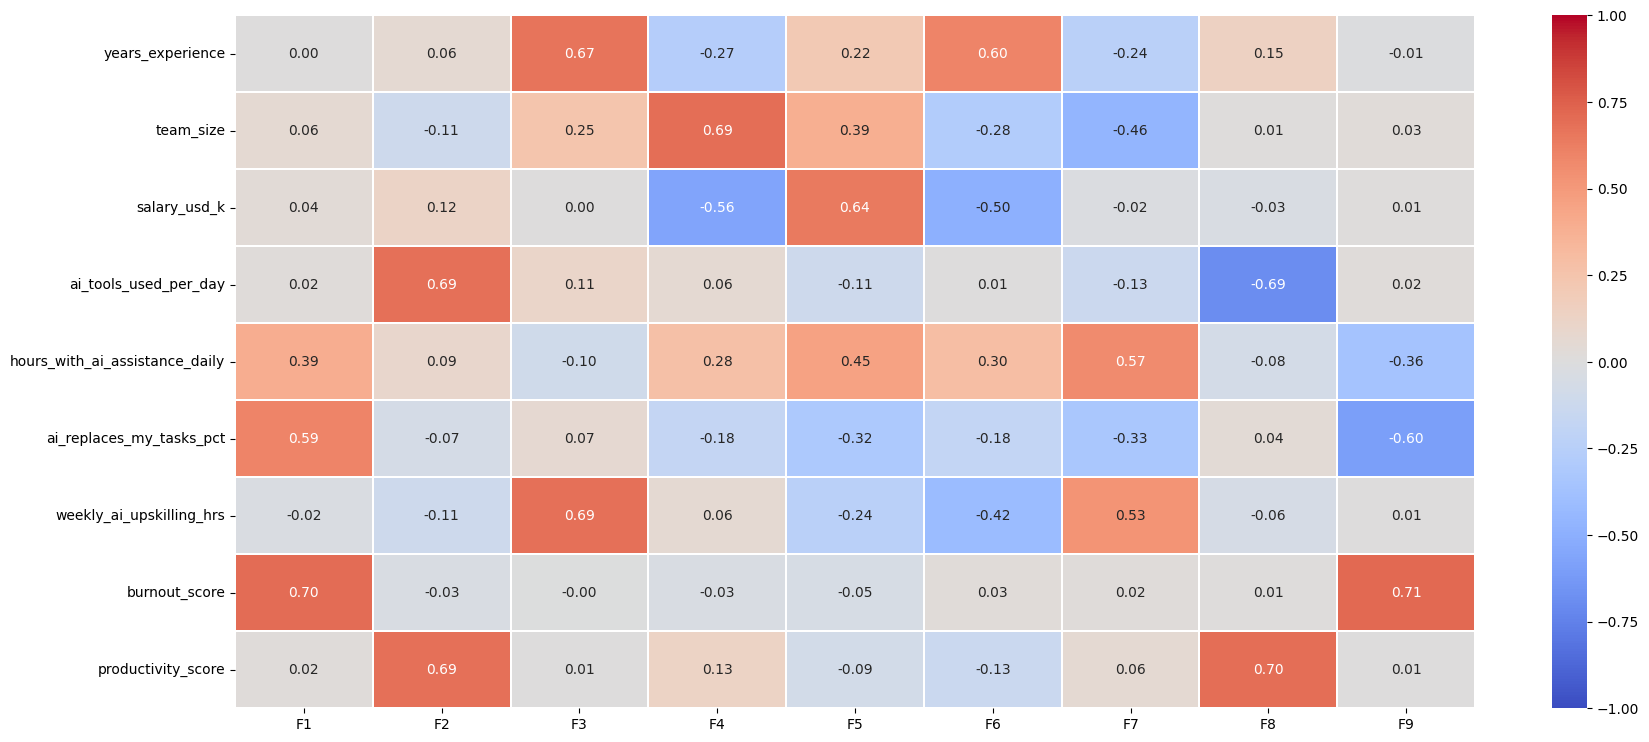

In [98]:
# Initialisation de la figure
plt.figure(figsize=(20,9))

# carte de chaleur
sns.heatmap(data=pcs.T,annot=True,fmt=".2f",vmin=-1,vmax=1,linewidth=0.05,cmap="coolwarm")

# affichage de la figure
plt.show()

## 3.5 Graphe des corrélations

In [ ]:
# fonction pour afficher le graphe des corrélations de deux axes

def corr_graph(x_y:tuple,features:list[str],pca:PCA,pcs:pd.DataFrame,figsize=(12,9),):
    """_summary_

    Args:
        x_y (tuple): les axes sous forme de tuples
        features (list[str]): la liste des features
        pca (PCA): PCA
        pcs (pd.DataFrame): dataframe de la matrice des composantes
        figsize (tuple, optional): dimension du graphique. Defaults to (12,9).
    """

    if len(x_y) > 2:
        raise ValueError("Deux axes sont demandées")

    # initialisation des axes
    x, y = x_y

    # initialisation du graphique
    fig, ax = plt.subplots(figsize=(12, 9))

    # tracée des flêches
    # pour chaque features :
    for i in range (len(features)):

        # coordonnées de x et y pour la feature i
        dx = pcs.iloc[x, i]
        dy = pcs.iloc[y, i]

        # la flêche commence à (0,0) et aux coordonnées dx,dy
        ax.arrow(
            0,
            0,
            dx=dx,
            dy=dy,
            width=0.02,
            head_width=0.04,
            head_length=0.03,

        )

        # le nom de la feature
        ax.text(x=dx+0.05,y=dy+0.05,s=features[i])


    # tracée du cercle
    theta = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(theta), np.sin(theta))

    # pour rendre le cercle rond
    plt.axis('equal')

    # tracée des axes
    plt.plot([-1, 1], [0, 0], c="grey", alpha=0.8, ls="--")
    plt.plot([0, 0], [-1, 1], c="grey", alpha=0.8, ls="--")

    # labels des axes
    plt.xlabel(f"F{x+1} ({pca.explained_variance_ratio_[x]:.2%}%)")
    plt.ylabel(f"F{y+1} ({pca.explained_variance_ratio_[y]:.2%}%)")

    # titre du graphique
    plt.title(f"Graphe des corrélations de F{x+1} et F{y+1}")

    # affichage du graphique
    plt.show()

### 3.5.1 Cas de  F1 et F2

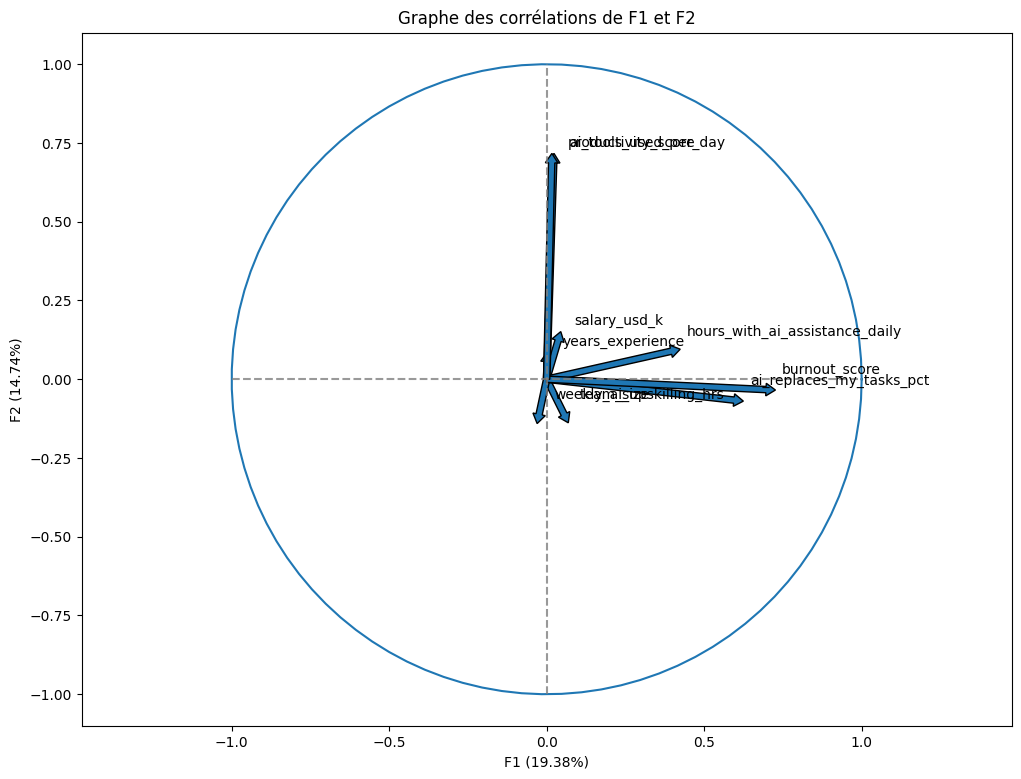

In [95]:
# initialisation des axes
x_y=0,1

# graphique
corr_graph(x_y=x_y,features=features,pca=pca,pcs=pcs)

### 3.5.2 Cas de F3 et F4

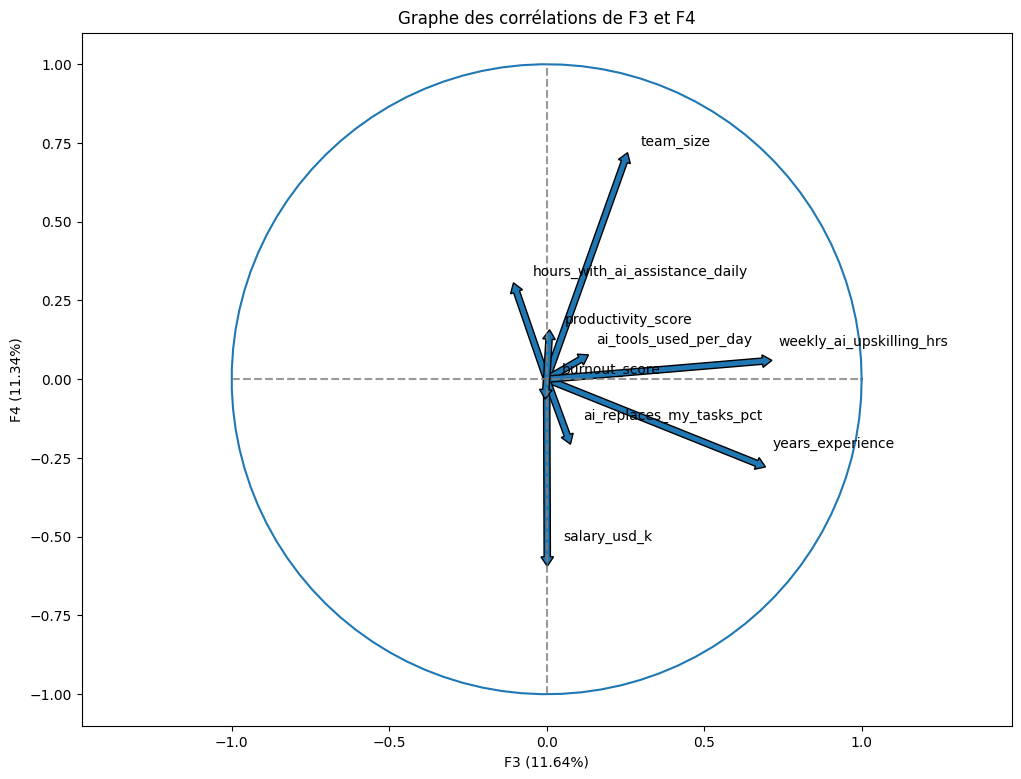

In [96]:
# initialisation des axes
x_y = 2,3

# graphique
corr_graph(x_y=x_y, features=features, pca=pca, pcs=pcs)

### 3.5.3 Cas de F5 et F6

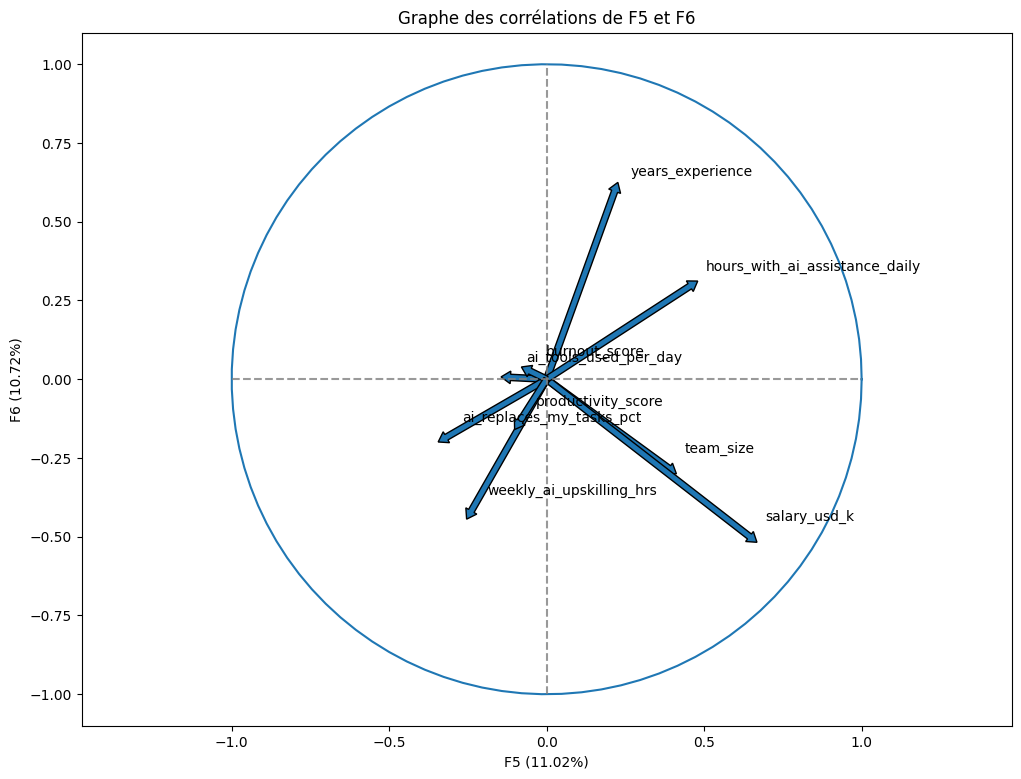

In [97]:
# initialisation des axes
x_y = 4, 5

# graphique
corr_graph(x_y=x_y, features=features, pca=pca, pcs=pcs)

# 4. Clustering

## 4.1 Matrice des points projetés

In [101]:
# matrice des points projetés
X_Projected = pca.transform(X_Scaled)

# affichage d'un extrait
X_Projected[:5]

array([[-3.75006669e-01, -9.31899869e-01, -6.99561481e-01,
        -1.65243477e+00, -6.96466242e-01, -7.97139437e-01,
        -9.42679608e-03,  1.18440676e+00,  1.17323326e+00],
       [ 1.52949220e-01, -6.65824814e-01,  5.87920014e-02,
         1.36756076e+00, -2.17321193e+00, -1.49888271e+00,
        -1.38007562e+00,  8.28091199e-01, -5.73809577e-01],
       [-1.28331594e+00, -5.30773517e-01, -4.85798613e-01,
         6.20509747e-01,  8.24412790e-01, -1.31025942e+00,
         1.78249534e-01, -7.30268359e-01, -2.28720812e-01],
       [ 1.94952019e+00,  1.75937189e+00,  9.27172733e-04,
        -1.29321115e+00, -7.61191037e-01,  1.32899804e+00,
        -8.79131295e-01,  1.29613533e+00,  9.22788618e-02],
       [ 1.52719992e-01,  8.59896855e-01, -1.09512102e+00,
        -1.55316423e-01, -1.70739502e+00, -2.68888965e-01,
        -1.66563833e+00, -8.83672678e-01,  3.08990439e-01]])

## 4.2 Choix du nombre de clusters
Nous allons initialiser un k-means pour différentes valeurs de k et enregistrer les inerties afin de réaliser le diagramme de l'inertie en fonction du nombre de clusters et choisir celui qui convient le mieux .

In [119]:
# liste des valeurs possible de k
k_list = [i+1 for i in range(10)]

# liste vide pour les inerties
inertia_list = []

In [120]:

# pour chaque k
for k in k_list :

    # on instancie un KMeans
    kmeans = KMeans(n_clusters=k)

    # on l'entraine
    kmeans.fit(X_Scaled)

    # on enregistre l'inerie
    inertia_list.append(kmeans.inertia_)

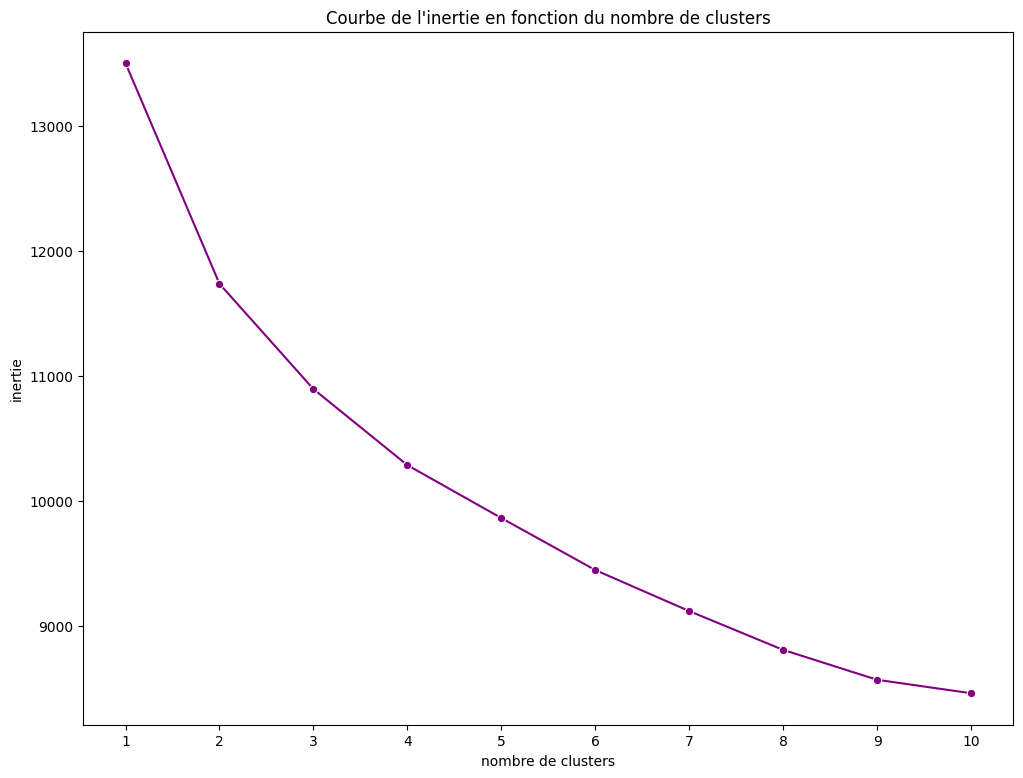

In [122]:
# transformation des k en label pour l'axe des absisses
k_labels = [str(i) for i in k_list]

# initialisation de la figure
plt.figure(figsize=(12,9))

# courbe
sns.lineplot(x=k_labels,y=inertia_list,c='purple',marker='o')

# titre et labels des axes
plt.xlabel("nombre de clusters")
plt.ylabel("inertie")
plt.title("Courbe de l'inertie en fonction du nombre de clusters")

# affichage
plt.show()

Nous allons choisirs 3 comme nombre de clusters

## 4.3 Clusters

In [143]:
# nombre de clusters
n_clusters = 3

# instanciation du KMeans
kmeans = KMeans(n_clusters=n_clusters)

# entrainement
kmeans.fit(X_Scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [144]:
# clusters
clusters = kmeans.labels_

# affichage
clusters[:5]

array([1, 2, 1, 2, 0], dtype=int32)

## 4.4 Projection sur les axes facorielles

In [145]:
def project_factorials_planes(
    x_y: tuple,
    clusters: np.array,
    pca: PCA,figsize = (12, 9)
):
    """_summary_

    Args:
        x_y (tuple): les axes
        clusters (np.array): les clusters
        pca (PCA): PCA
        figsize (tuple, optional): dimensiosn de la figure. Defaults to (12, 9).
    """

    # initalisation des axes
    x,y=x_y

    # initialisation de la figure
    fig,ax = plt.subplots(figsize=figsize)

    # nuage de points
    sns.scatterplot(x=X_Projected[:,x],y=X_Projected[:,y],hue=clusters,palette="plasma")

    # initialisation des limites des axes
    x_max = np.abs(X_Projected[:,x]).max() *1.1
    y_max = np.abs(X_Projected[:,y]).max() *1.1

    # bornes des axes
    plt.xlim(left=-x_max, right=x_max)
    plt.ylim(bottom=-y_max,top=y_max)

    # tracé des axes
    plt.plot([-x_max,x_max],[0,0],c="grey",ls='--',alpha=0.8)
    plt.plot( [0, 0], [-y_max,y_max],c="grey", ls="--", alpha=0.8)

    # labels des axes
    plt.xlabel(f"F{x+1} ({pca.explained_variance_ratio_[x]:.2%}%)")
    plt.ylabel(f"F{y+1} ({pca.explained_variance_ratio_[y]:.2%}%)")

    # titre du graphique
    plt.title(f"Projection du nuage des individus sur F{x+1} et F{y+1}")

    # affichage du graphique
    plt.show()

### 4.4.1 Cas de F1 et F2

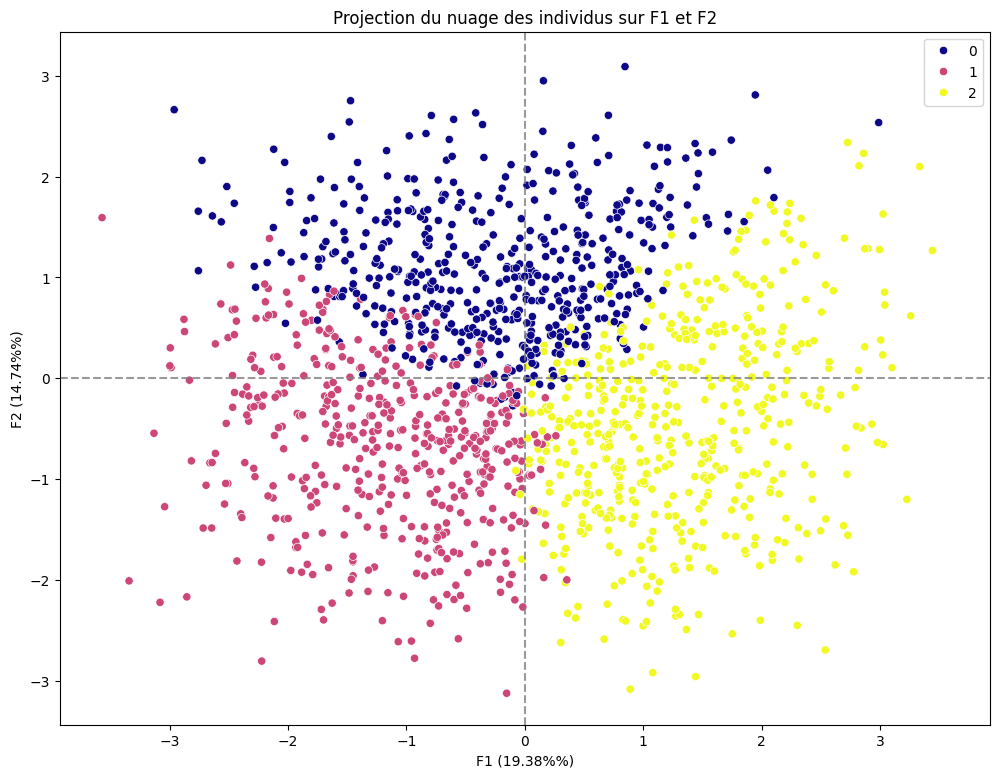

In [146]:
# initialisation des axes
x_y=0,1

# projection
project_factorials_planes(x_y=x_y,clusters=clusters,pca=pca)

### 4.4.2 Cas de F3 et F4

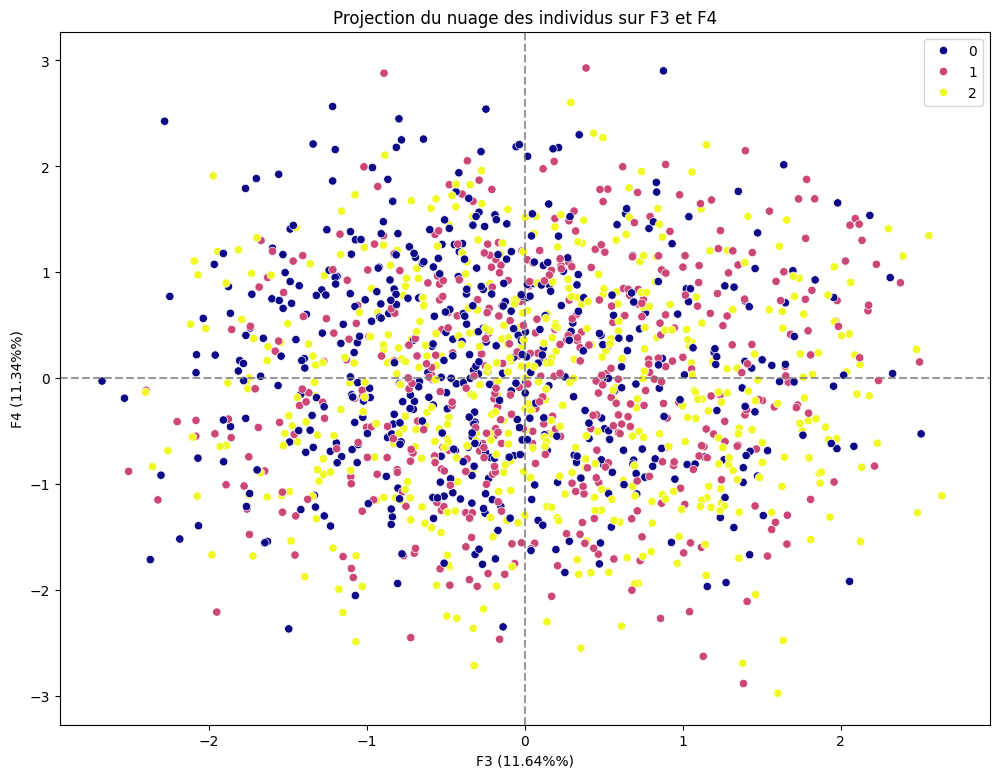

In [147]:
# initialisation des axes
x_y = 2, 3

# projection
project_factorials_planes(x_y=x_y, clusters=clusters, pca=pca)

### 4.4.3 Cas de F5 et F6

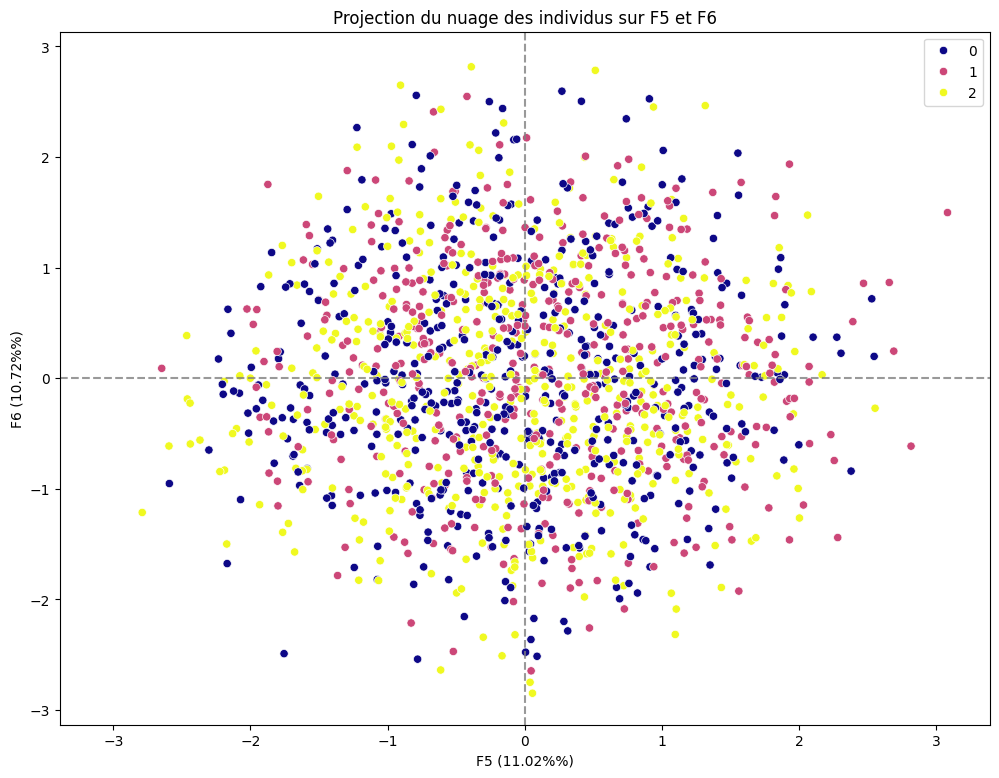

In [148]:
# initialisation des axes
x_y = 4,5

# projection
project_factorials_planes(x_y=x_y, clusters=clusters, pca=pca)